In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [162]:

#%cd '/Users/grushinda/Документы /Учеба/МИФИ/Классическое машинное обучение/HomeWorkers/Сессионная задача/KAGLE_Scintillation Detector_GrushinDA/EDA'
#!ls

In [163]:
tmp_data = pd.read_csv('data/features.csv')

In [164]:
go_data = tmp_data.copy()

In [165]:
go_data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  23479 non-null  int64  
 1   MEAN        23479 non-null  float64
 2   STD         23479 non-null  float64
 3   SKEWNESS    23479 non-null  float64
 4   KURTOSIS    23479 non-null  float64
 5   MAX_VAL     23479 non-null  int64  
 6   LONG_AREA   23479 non-null  int64  
 7   SHORT_AREA  23479 non-null  int64  
 8   PSD         23479 non-null  float64
 9   MAX_DIFF    23479 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 1.8 MB


In [166]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler


X = go_data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    "KMeans": (
        KMeans(random_state=42), 
        {
            "n_clusters": [3],
            "init": ["k-means++"],
            "n_init": [30, 50, 70],
            "algorithm": ['lloyd', 'elkan']
            
        }
    ),

    "SpectralClustering": (
        SpectralClustering(random_state=42), 
        {
            "n_clusters":[3],
            "affinity": ["nearest_neighbors"],
            "n_neighbors": [5, 8, 14, 42],
            "assign_labels":  ['kmeans']
        }
    )

    #"HDBSCAN": (
    #    HDBSCAN(), 
    #    {
    #        "min_cluster_size":[100],
    #        "min_samples": [1, 5, 10],
    #        "metric": ["euclidean"]
    #    }
    #)
}


In [168]:
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterGrid

# Перебор моделей
best_score = 2.0  #
best_model = None
best_params = None
best_labels = None
results_report = []

for name, (in_model, param_grid) in models.items():
    print(f"Обучаем {name}...")

    grid = ParameterGrid(param_grid)

    for params in grid:

        model = in_model.set_params(**params)

        labels = model.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if 1 < n_clusters < len(X_scaled):
            #score = silhouette_score(X_scaled, labels)
            score = davies_bouldin_score(X_scaled, labels)
            
            if score < best_score:
                best_score = score
                best_params = params
                best_model = model
                best_labels = labels

        unique_elements, counts_elements = np.unique(labels, return_counts=True)


        results_report.append({"Model": name, 
                               "Score": score,  # type: ignore
                               "uniq": unique_elements, "count":counts_elements, # type: ignore
                               "Params": params, 
                               "Count": n_clusters}) 
    

# --- АНАЛИЗ ---
print("\n--- Report  ---")
print(pd.DataFrame(results_report))
print(f"\n Лучшая модель: {best_model}")

Обучаем KMeans...


Обучаем SpectralClustering...

--- Report  ---
                 Model     Score       uniq                count  \
0               KMeans  1.053403  [0, 1, 2]  [9572, 10754, 3153]   
1               KMeans  1.053403  [0, 1, 2]  [9572, 10754, 3153]   
2               KMeans  1.053767  [0, 1, 2]  [3172, 9574, 10733]   
3               KMeans  1.053403  [0, 1, 2]  [9572, 10754, 3153]   
4               KMeans  1.053403  [0, 1, 2]  [9572, 10754, 3153]   
5               KMeans  1.053767  [0, 1, 2]  [3172, 9574, 10733]   
6   SpectralClustering  1.121111  [0, 1, 2]  [8860, 12576, 2043]   
7   SpectralClustering  1.114762  [0, 1, 2]  [2132, 8911, 12436]   
8   SpectralClustering  1.111936  [0, 1, 2]  [12372, 8901, 2206]   
9   SpectralClustering  1.101690  [0, 1, 2]  [8770, 12232, 2477]   
10  SpectralClustering  1.092268  [0, 1, 2]  [8715, 12015, 2749]   

                                               Params  Count  
0   {'algorithm': 'lloyd', 'init': 'k-means++', 'n...      3  
1   {'algo

In [ ]:
#go_model = SpectralClustering(random_state=42, n_clusters=3, affinity='nearest_neighbors', n_neighbors=41, assign_labels='kmeans' )
#go_labels = go_model.fit_predict(X_scaled)

#go_labels = best_labels
#display(pd.DataFrame(results_report))

In [ ]:
#unique_elements, counts_elements = np.unique(go_labels, return_counts=True)
#print(unique_elements, counts_elements )

[0 1 2] [12367  8895  2217]


In [261]:
for i in range(8, 9): 
    go_model = SpectralClustering(random_state=42, n_clusters=3, affinity='nearest_neighbors', n_neighbors=i, assign_labels='kmeans' )
    go_labels = go_model.fit_predict(X_scaled)
    unique_elements, counts_elements = np.unique(go_labels, return_counts=True)
    print(i, ':', unique_elements, counts_elements )

8 : [0 1 2] [12798  9054  1627]


In [262]:
(pd.DataFrame(go_labels, columns=['cluster'])
 .reset_index()
 .to_csv('data/labels.csv', index=False))

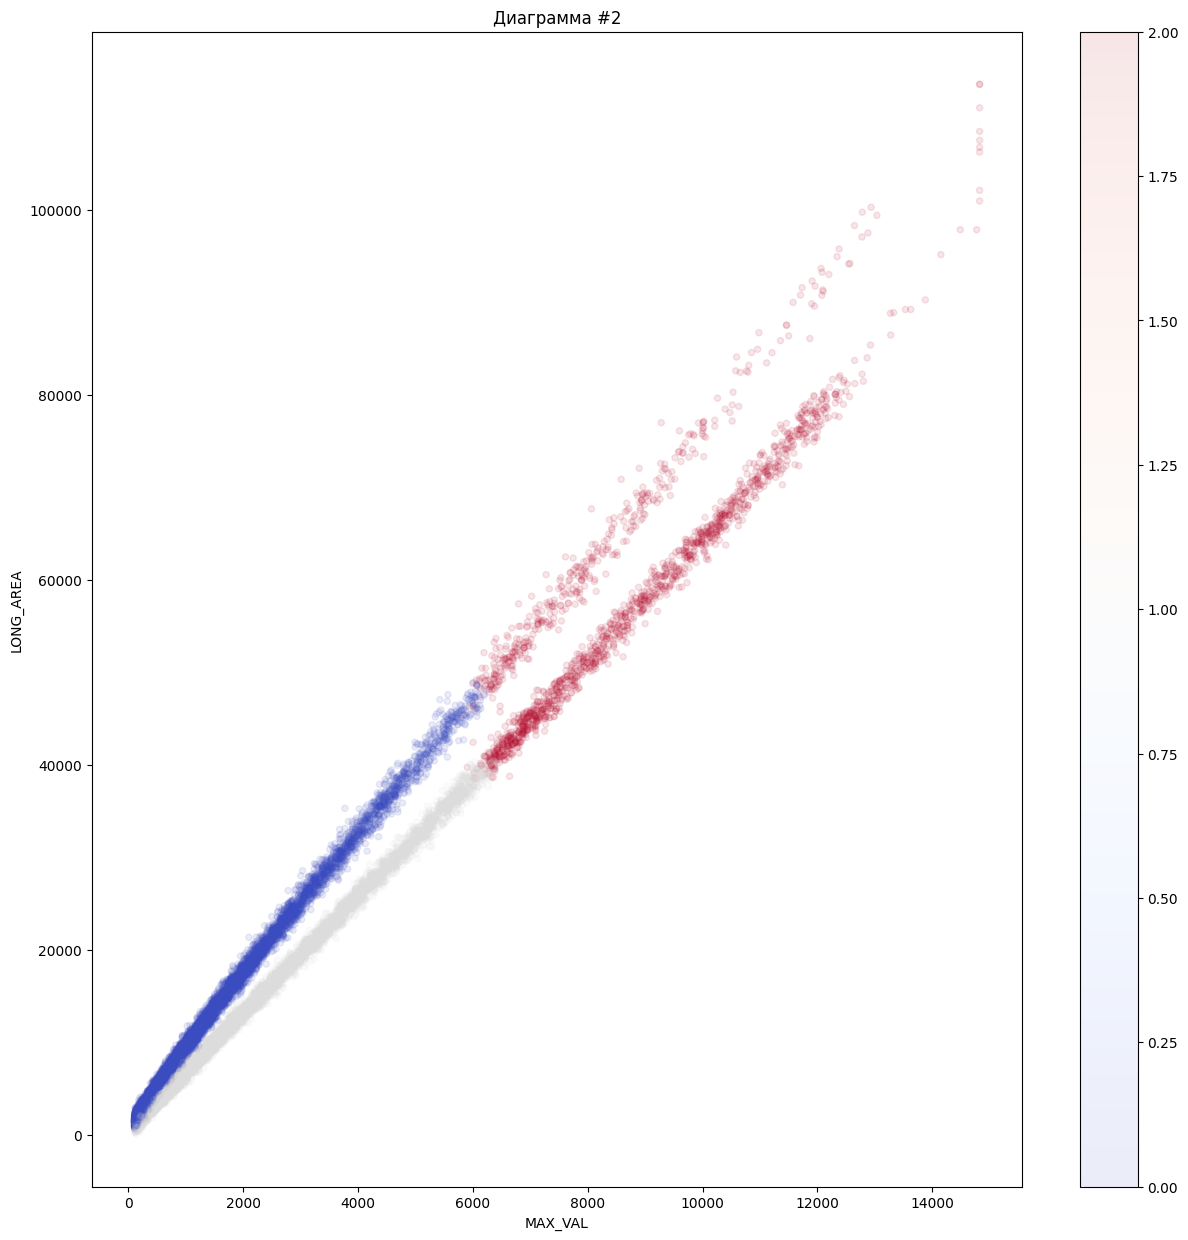

In [263]:
ax = go_data.plot.scatter(
    y='LONG_AREA', 
    x='MAX_VAL', 
    c=go_labels, # type: ignore
    cmap='coolwarm',
    alpha=0.1, 
    figsize=(15,15)
)
ax.set_title('Диаграмма #2')
ax.set_xlabel('MAX_VAL')
ax.set_ylabel('LONG_AREA')
plt.show()

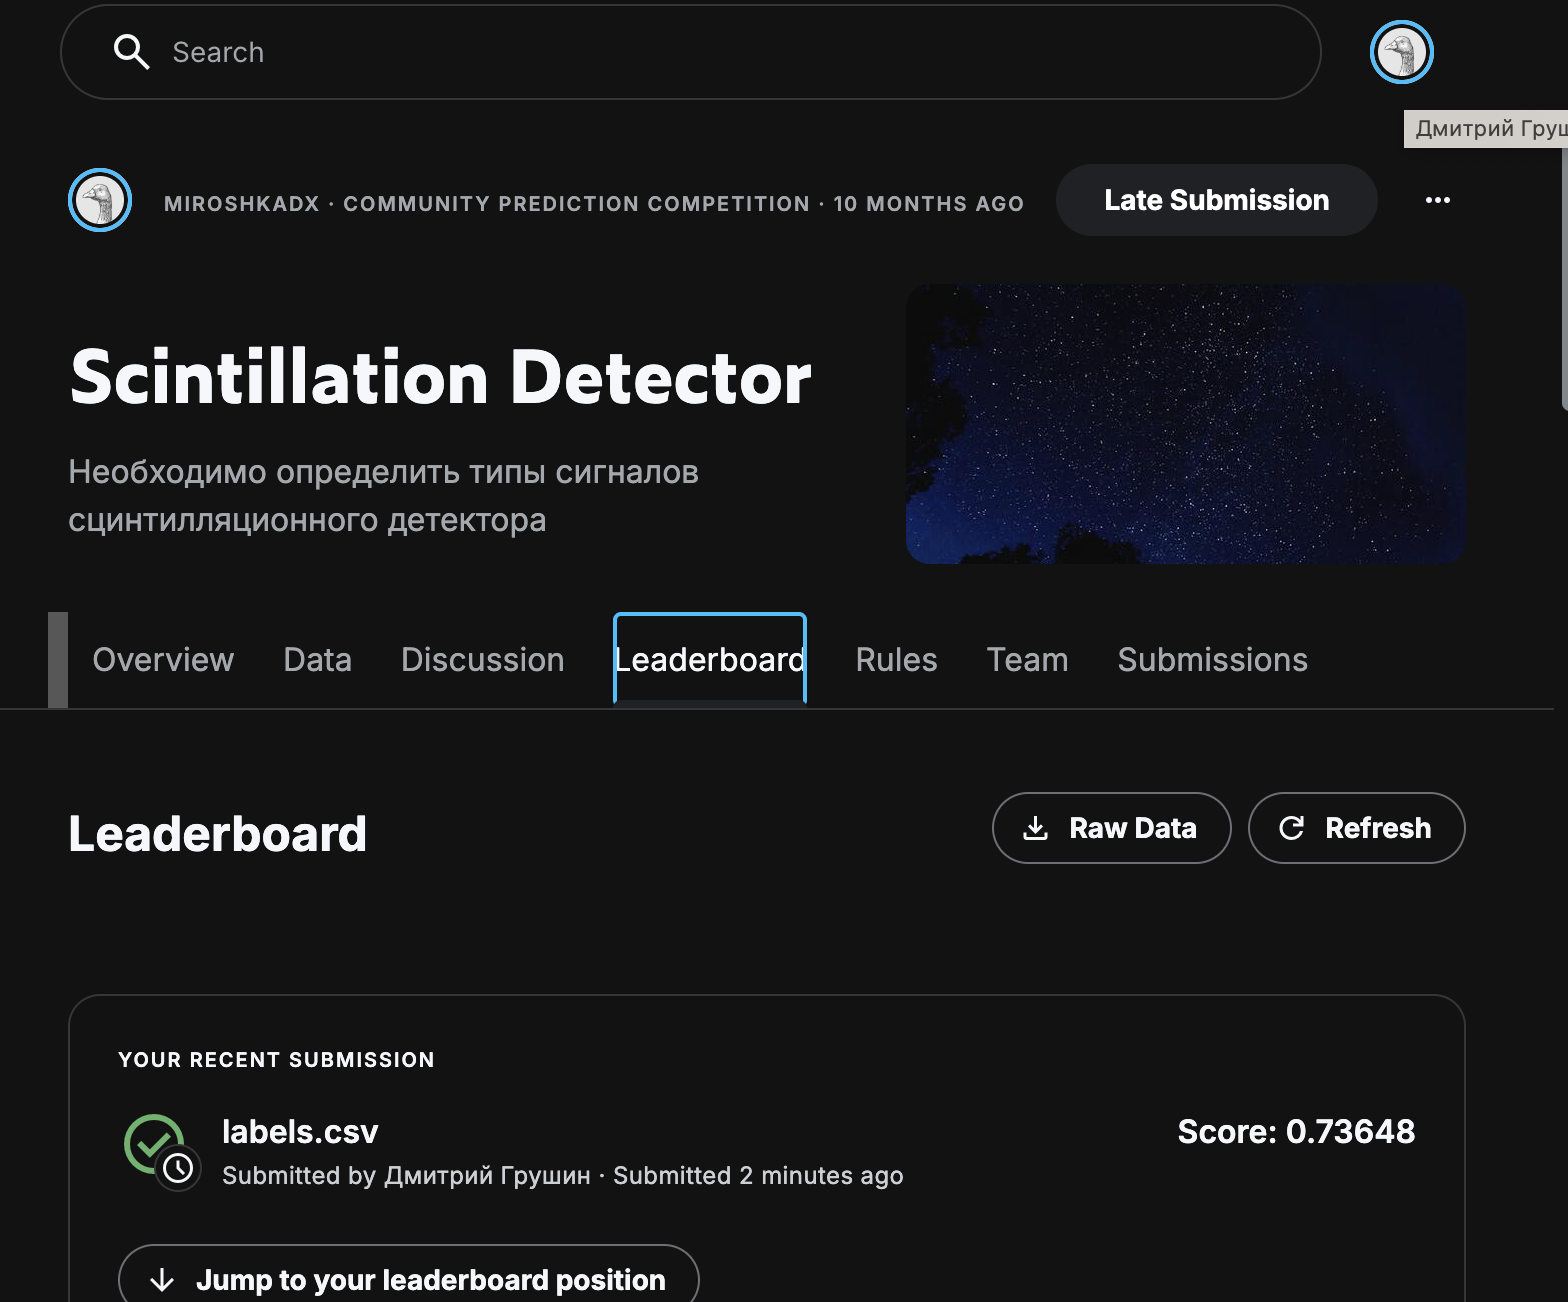

Выводы: 
1) Модели HDBSCAN и DBSCAN плохо подошли для решения данной задачи 
2) Подборка гиперпараметров для SpectralClustering выполнялась в два этапа:
 - выбор метода по общим характеристкам 
 - подбор кол-ва соседний для алгоритма kmeans 

3) На представленном выше гргафике видно что алгоритм верно разделили два сигнала, однако довольно большие хвосты отнес к прочим. 


В качестве улучшения можели можно рассмотретьь :
1) сдвинуть сигалы к пиковым значеним - отрезатьь левые хвосты - сейчас расчет  long был с  нимим
2) убрать выбросы - скачки в правом хвосте сигнала 
3) Добавить параметры по скоросте возрастания и убывания сиггнала : за сколько индексов сигнал достгает пика и как быстро они достгает минимума. 

Это должно дать более четое разбиение на две вершины (график в EDA)